In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits

In [3]:
print('Problem 1\n')

#with loop:
loop_arr = []
for i in range (0,300):
    temp_row = []
    for j in range(0,200):
        temp_row.append(i)
    loop_arr.append(temp_row)
loop_arr = np.array(loop_arr, dtype = np.float64)
print(loop_arr, np.shape(loop_arr))

#that took way longer than i wanna admit it was so much simplier than i thought lol


Problem 1

[[  0.   0.   0. ...   0.   0.   0.]
 [  1.   1.   1. ...   1.   1.   1.]
 [  2.   2.   2. ...   2.   2.   2.]
 ...
 [297. 297. 297. ... 297. 297. 297.]
 [298. 298. 298. ... 298. 298. 298.]
 [299. 299. 299. ... 299. 299. 299.]] (300, 200)


In [4]:
#without loop:
arr = np.zeros((200, 300), dtype = np.float64)
col = np.arange(300, dtype = np.float64) 
arr[:] = col
arr = np.transpose(arr) #i dont know how to make a column vector?
#i feel like i did in the past but i dont remember aside from transposing before
print(arr, np.shape(arr))
#that was a lot faster

[[  0.   0.   0. ...   0.   0.   0.]
 [  1.   1.   1. ...   1.   1.   1.]
 [  2.   2.   2. ...   2.   2.   2.]
 ...
 [297. 297. 297. ... 297. 297. 297.]
 [298. 298. 298. ... 298. 298. 298.]
 [299. 299. 299. ... 299. 299. 299.]] (300, 200)


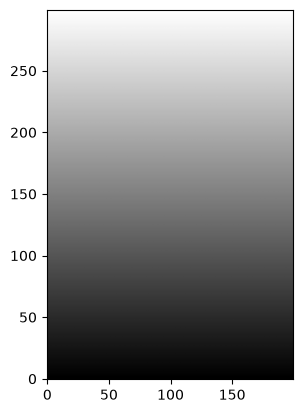

In [5]:
#plotting time:
plt.imshow(arr, cmap = 'gray', origin = 'lower') #imshow for the color map
plt.show()
#hell yeah


Problem 2

loop array: (300, 200) float64
no-loop array: (300, 200) float64
arrays match: True
arr[26, 171] = 26.0  (expected y = 26.0)
arr[232, 17] = 232.0  (expected y = 232.0)
arr[196, 139] = 196.0  (expected y = 196.0)
arr[131, 40] = 131.0  (expected y = 131.0)
arr[129, 18] = 129.0  (expected y = 129.0)
corners: lower-left 0.0 lower-right 0.0 upper-left 299.0 upper-right 299.0


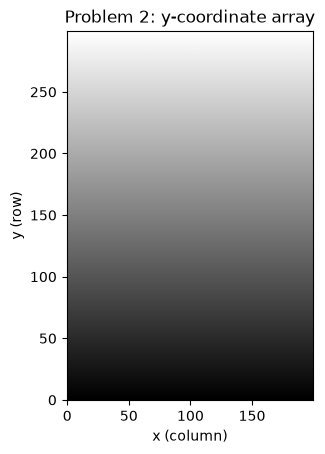

In [7]:
print('\nProblem 2\n')

# Prompt used (screenshot of assignment + this ask):
# "Repeat problem 1 with AI help. Make a 300x200 float64 array where each
# element is its own y-coordinate (y=0 at the first row, y=299 at the last).
# Do it with a loop and without loops. Plot with imshow, cmap='gray',
# origin lower-left = (0,0). Check random elements and the dtype."

ny, nx = 300, 200

# --- with a loop ---
arr_loop = np.empty((ny, nx), dtype=np.float64)
for y in range(ny):
    for x in range(nx):
        arr_loop[y, x] = y

# --- without any loops (broadcast a column of y values) ---
arr = np.arange(ny, dtype=np.float64)[:, np.newaxis] * np.ones((1, nx), dtype=np.float64)

print('loop array:', arr_loop.shape, arr_loop.dtype)
print('no-loop array:', arr.shape, arr.dtype)
print('arrays match:', np.array_equal(arr_loop, arr))

# spot-check randomly placed elements: value should equal the y (row) index
rng = np.random.default_rng(42)
ys = rng.integers(0, ny, size=5)
xs = rng.integers(0, nx, size=5)
for y, x in zip(ys, xs):
    print(f'arr[{y}, {x}] = {arr[y, x]}  (expected y = {float(y)})')

print('corners: lower-left', arr[0, 0], 'lower-right', arr[0, -1],
      'upper-left', arr[-1, 0], 'upper-right', arr[-1, -1])

plt.imshow(arr, cmap='gray', origin='lower')
plt.xlabel('x (column)')
plt.ylabel('y (row)')
plt.title('Problem 2: y-coordinate array')
plt.show()



Problem 3

Filename: m42_40min_ir.zip
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     129   (2376, 2381)   int16   


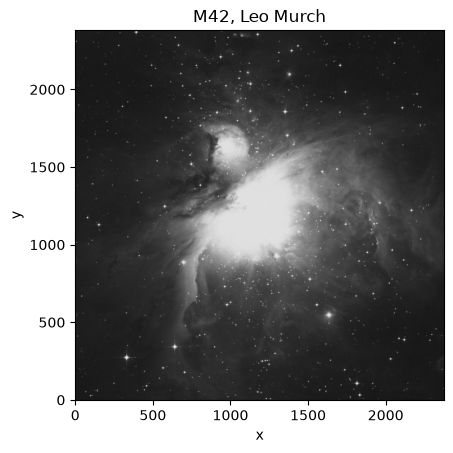

In [24]:
print('\nProblem 3\n')

#fileio it
with fits.open('m42_40min_ir.zip') as hdu_list: #get this from the fits site
    hdu_list.info()
    #image data w/in 1st index:
    image_data = hdu_list[0].data
    plt.imshow(image_data, cmap='gray', origin = 'lower') #wow thats so cool
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title("M42, Leo Murch") #looks to fit within the boundaries to me?
    plt.savefig('p1_aleonav_problem3_graph1.png')

    #for mem
    hdu_list.close()
